In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
data= pd.read_csv('/content/cookie_cats.csv')

In [5]:
data.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [6]:
data.shape

(90189, 5)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [8]:
data.isnull().sum()

,0
userid,0
version,0
sum_gamerounds,0
retention_1,0
retention_7,0


In [9]:
data['version'].value_counts()

,count
version,
gate_40,45489
gate_30,44700


data cleaning

In [10]:
data.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [15]:
data[data['sum_gamerounds']==0].value_counts()

,,,,,count
userid,version,sum_gamerounds,retention_1,retention_7,
9998285,gate_30,0,False,False,1
1066,gate_30,0,False,False,1
2101,gate_30,0,False,False,1
3095,gate_30,0,False,False,1
4076,gate_40,0,False,False,1
...,...,...,...,...,...
15962,gate_30,0,False,False,1
11297,gate_30,0,False,False,1
10637,gate_40,0,False,False,1


In [16]:
data.nlargest(5,'sum_gamerounds')

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


In [19]:
data= data[data['sum_gamerounds'] != 0]

In [21]:
data= data[data['sum_gamerounds'] <= 3000 ]

In [22]:
data.shape

(86194, 5)

In [23]:
data['version'].value_counts()

,count
version,
gate_40,43432
gate_30,42762


eda

In [25]:
data.groupby('version')['retention_1'].mean()

,retention_1
version,
gate_30,0.467541
gate_40,0.462171


In [26]:
data.groupby('version')['retention_7'].mean()

,retention_7
version,
gate_30,0.198424
gate_40,0.190321


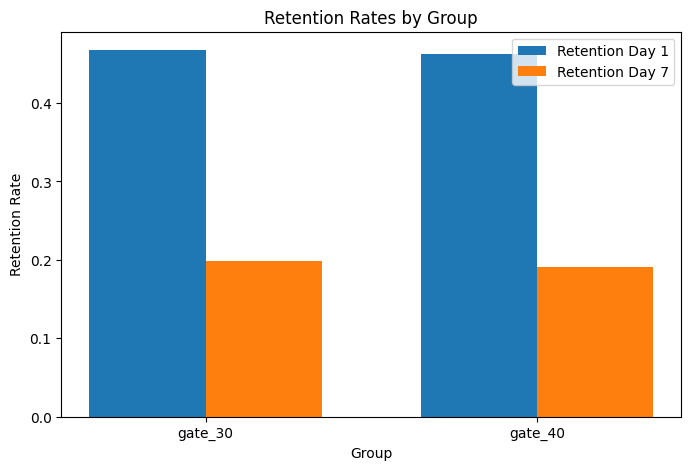

In [29]:


# Calculate retention rates by group
retention_rates = data.groupby('version')[['retention_1', 'retention_7']].mean()

# X-axis positions
groups = retention_rates.index
x = np.arange(len(groups))
width = 0.35

# Create side-by-side bars
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, retention_rates['retention_1'], width, label='Retention Day 1')
plt.bar(x + width/2, retention_rates['retention_7'], width, label='Retention Day 7')

# Labels and formatting
plt.xlabel('Group')
plt.ylabel('Retention Rate')
plt.title('Retention Rates by Group')
plt.xticks(x, groups)
plt.legend()
plt.show()

<Axes: >

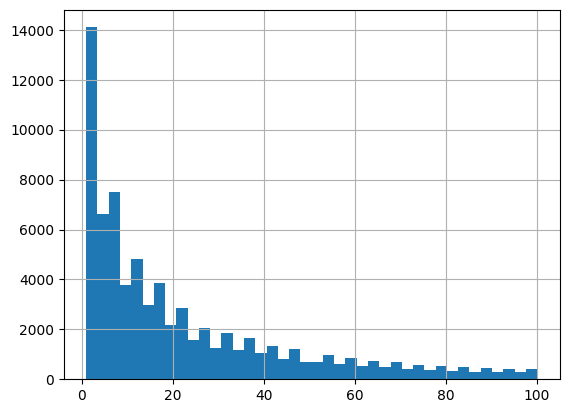

In [30]:
data[data['sum_gamerounds'] <= 100]['sum_gamerounds'].hist(bins=40)

hypothesis testing

In [31]:
pd.crosstab(data['version'], data['retention_7'])

retention_7,False,True
version,,
gate_30,34277,8485
gate_40,35166,8266


In [32]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(data['version'], data['retention_7'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi2: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")

Chi2: 8.984877907964687
P-value: 0.0027222297777463066
Degrees of freedom: 1


In [33]:
contingency_table_1 = pd.crosstab(data['version'], data['retention_1'])
chi2, p, dof, expected = chi2_contingency(contingency_table_1)
print(f"P-value retention_1: {p}")

P-value retention_1: 0.11554308221600512


In [38]:
##bootstrapping
boot_30 = []
boot_40 = []

for i in range(10000):
    sample = data.sample(frac=1, replace=True)
    boot_30.append(sample[sample['version']=='gate_30']['retention_7'].mean())
    boot_40.append(sample[sample['version']=='gate_40']['retention_7'].mean())

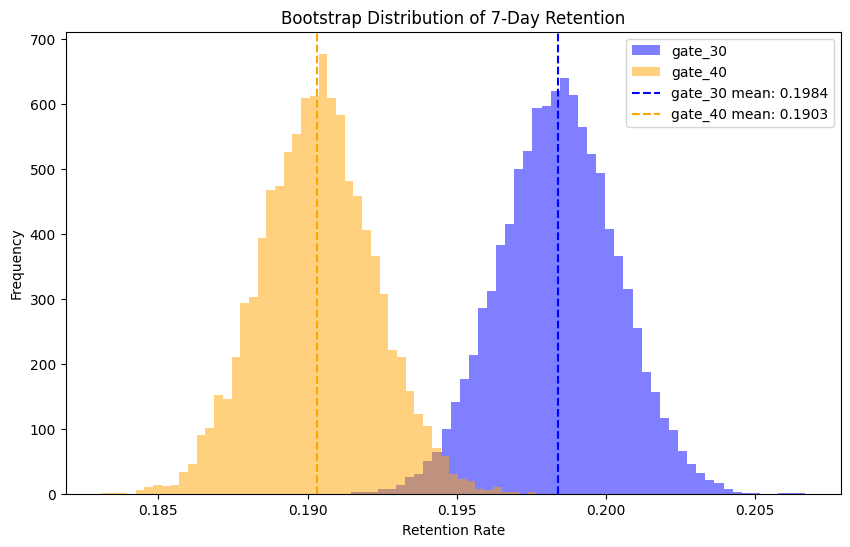

In [39]:
plt.figure(figsize=(10,6))
plt.hist(boot_30, bins=50, alpha=0.5, label='gate_30', color='blue')
plt.hist(boot_40, bins=50, alpha=0.5, label='gate_40', color='orange')
plt.axvline(x=np.mean(boot_30), color='blue', linestyle='--', label=f'gate_30 mean: {np.mean(boot_30):.4f}')
plt.axvline(x=np.mean(boot_40), color='orange', linestyle='--', label=f'gate_40 mean: {np.mean(boot_40):.4f}')
plt.title('Bootstrap Distribution of 7-Day Retention')
plt.xlabel('Retention Rate')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [40]:
print(f"gate_30 95% CI: ({np.percentile(boot_30, 2.5):.4f}, {np.percentile(boot_30, 97.5):.4f})")
print(f"gate_40 95% CI: ({np.percentile(boot_40, 2.5):.4f}, {np.percentile(boot_40, 97.5):.4f})")

gate_30 95% CI: (0.1946, 0.2022)
gate_40 95% CI: (0.1866, 0.1941)
